In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset/documents.csv
/kaggle/input/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset/single_passage_answer_questions.csv
/kaggle/input/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset/no_answer_questions.csv
/kaggle/input/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset/multi_passage_answer_questions.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data_doc = pd.read_csv("/kaggle/input/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset/documents.csv")
df_doc = pd.DataFrame(data_doc)
df_doc.head()

,index,source_url,text
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...


In [4]:
df_doc.shape

(20, 3)

In [5]:
df_doc.duplicated().sum()

np.int64(0)

In [6]:
df_doc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   index       20 non-null     int64 
 1   source_url  20 non-null     object
 2   text        20 non-null     object
dtypes: int64(1), object(2)
memory usage: 612.0+ bytes


In [7]:
df_doc.columns

Index(['index', 'source_url', 'text'], dtype='object')

In [8]:
df_doc["source_url"].head()

0    https://enterthegungeon.fandom.com/wiki/Bullet...
1    https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...
2    https://bytes-and-nibbles.web.app/bytes/stici-...
3                https://github.com/llmware-ai/llmware
4                  https://docs.marimo.io/recipes.html
Name: source_url, dtype: object

In [9]:
df_doc["text"].str.len().describe()

count        20.000000
mean      35862.300000
std       45832.721225
min        2750.000000
25%       13026.500000
50%       20250.500000
75%       39751.250000
max      211782.000000
Name: text, dtype: float64

In [10]:
df_doc["text"].str.split().str.len().describe()

count       20.000000
mean      5797.100000
std       7427.437894
min        470.000000
25%       2255.000000
50%       3137.500000
75%       6167.750000
max      34764.000000
Name: text, dtype: float64

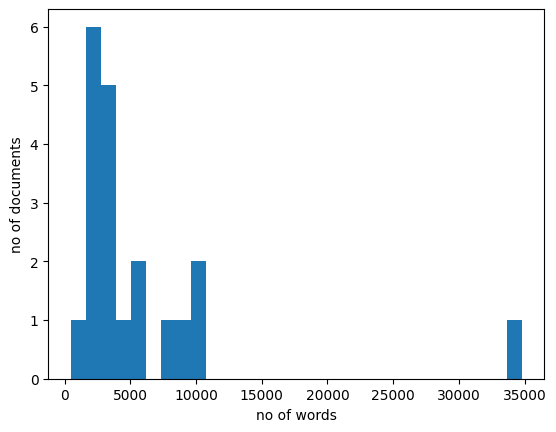

In [11]:
word_counts= df_doc["text"].str.split().str.len()

word_counts.plot(kind='hist',bins=30)
plt.xlabel("no of words")
plt.ylabel("no of documents")
plt.show()

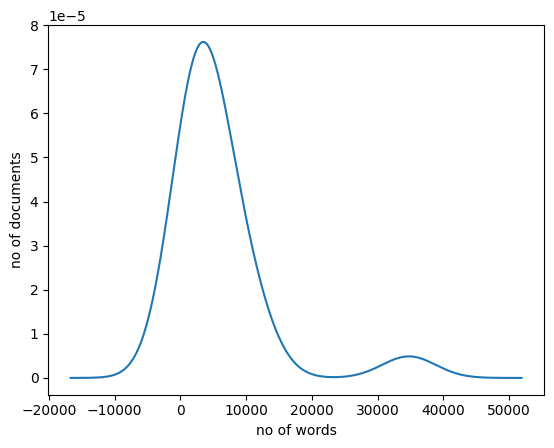

In [12]:
word_counts.plot(kind="kde")
plt.xlabel("no of words")
plt.ylabel("no of documents")
plt.show()

In [13]:
for i in range(3):
    print(f"\nDOCUMENT {i}")
    print(df_doc["text"].iloc[i][:1000])
    print("=" * 100)


DOCUMENT 0
Bullet Kin
Bullet Kin are one of the most common enemies. They slowly walk towards the player, occasionally firing a single bullet. They can flip tables and use them as cover. They will also deal contact damage if the player touches them.

Occasionally, Bullet Kin will have assault rifles, in which case they will rapidly fire 8 bullets towards the player before reloading. When an assault rifle wielding bullet kin appears, there will often be more in the same room.

On some occasions the player will also encounter incapacitated Bullet Kin lying on the floor. These Bullet Kin are props and disintegrate upon touch. They can be found in mass quantity in Oubliette.

In the Black Powder Mine, they can also ride Minecarts. In fact, if there are any unoccupied Minecarts within the room, they will take priority by walking towards them to ride in.

Trivia
Bullet Kin wield Magnums. Assault-rifle wielding Bullet Kin wield AK-47s.
Incapacitated Bullet Kin can be found in the Oublilette 

In [14]:
df_doc["text"].str.contains(r"\s{2,}", regex=True).sum()

np.int64(19)

In [15]:
df_doc["text"] = df_doc["text"].str.replace(r"\s+"," ",regex=True).str.strip()

In [16]:
df_doc["text"].str.contains(r"\s{2,}",regex=True).sum()

np.int64(0)

In [17]:
sample = df_doc["text"].iloc[0]
tokens=sample.split()
print(tokens[:30])
print("Number of tokens:", len(tokens))

['Bullet', 'Kin', 'Bullet', 'Kin', 'are', 'one', 'of', 'the', 'most', 'common', 'enemies.', 'They', 'slowly', 'walk', 'towards', 'the', 'player,', 'occasionally', 'firing', 'a', 'single', 'bullet.', 'They', 'can', 'flip', 'tables', 'and', 'use', 'them', 'as']
Number of tokens: 1845


In [18]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

examples = [
    "biometrics",
    "researchers",
    "unbelievable",
    "machine-learning"
]

for text in examples:
    print(text, "→", tokenizer.tokenize(text))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

biometrics → ['bio', '##metric', '##s']
researchers → ['researchers']
unbelievable → ['unbelievable']
machine-learning → ['machine', '-', 'learning']


In [19]:
token_counts = df_doc["text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

print(token_counts.describe())

Token indices sequence length is longer than the specified maximum sequence length for this model (2361 > 512). Running this sequence through the model will result in indexing errors


count       20.000000
mean      8214.650000
std       9997.129747
min        664.000000
25%       2878.500000
50%       4833.500000
75%       9792.250000
max      45309.000000
Name: text, dtype: float64


In [20]:
word_counts = df_doc["text"].str.split().str.len()

comparison = pd.DataFrame({
    "words": word_counts,
    "tokens": token_counts
})

print(comparison.head())

   words  tokens
0   1845    2361
1    470     664
2   3785    4843
3   3003    4913
4   1796    2929


In [21]:
from collections import Counter
words = " ".join(df_doc["text"]).split()

total_words = len(words)
unique_words = len(set(words))

print("Total words:", total_words)
print("Unique words:", unique_words)

Total words: 115942
Unique words: 22774


In [22]:
vocabulary_ratio = unique_words / total_words

print("Vocabulary ratio:", vocabulary_ratio)

Vocabulary ratio: 0.19642579910644978


In [23]:
word_freq = Counter(words)

print(word_freq.most_common(20))

[('the', 5387), ('to', 2730), ('a', 2466), ('of', 2345), ('and', 2345), ('in', 1646), ('for', 1129), ('is', 1028), ('Fixed', 1005), ('on', 930), ('with', 811), ('that', 792), ('you', 579), ('now', 570), ('The', 567), ('be', 560), ('can', 536), ('are', 518), ('I', 514), ('as', 501)]


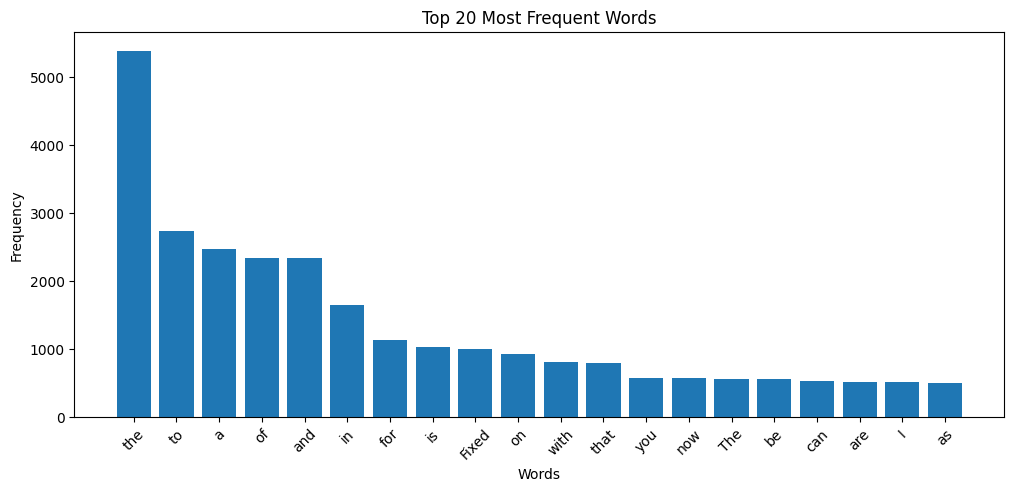

In [24]:
top_words = word_freq.most_common(20)

words_top = [word for word, count in top_words]
counts_top = [count for word, count in top_words]

plt.figure(figsize=(12, 5))
plt.bar(words_top, counts_top)
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")
plt.show()

In [25]:
print([word for word, count in word_freq.items() if count == 1][:30])

['bullet.', 'touches', 'Occasionally,', 'rifles,', 'rifle', 'kin', 'appears,', 'occasions', 'incapacitated', 'disintegrate', 'touch.', 'Powder', 'Mine,', 'Minecarts.', 'unoccupied', 'Minecarts', 'Magnums.', 'Assault-rifle', 'Incapacitated', 'Oublilette', "Cannon's", 'Oubliette', 'Agunim,', 'poking', 'barrels.', 'joke', 'gun', 'barrel.', '"Balùnculo",', 'portmanteau']


In [26]:
print("Missing:", df_doc["text"].isna().sum())

print(
    "Empty/blank:",
    df_doc["text"].fillna("").str.strip().eq("").sum()
)

Missing: 0
Empty/blank: 0


In [27]:
print("Duplicate documents:", df_doc["text"].duplicated().sum())

Duplicate documents: 0


In [28]:
print(
    "Documents with excessive whitespace:",
    df_doc["text"].str.contains(r"\s{2,}", regex=True).sum()
)

Documents with excessive whitespace: 0


In [29]:
df_doc["text"] = (
    df_doc["text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [30]:
print(
    "Remaining:",
    df_doc["text"].str.contains(r"\s{2,}", regex=True).sum()
)

Remaining: 0


In [31]:
import re

html_pattern = r"<[^>]+>"

print(
    "Documents containing HTML:",
    df_doc["text"].str.contains(html_pattern, regex=True).sum()
)

Documents containing HTML: 4


In [32]:
html_pattern = r"<[^>]+>"

html_docs = df_doc[
    df_doc["text"].str.contains(html_pattern, regex=True)
]

for i, text in html_docs["text"].items():
    matches = re.findall(html_pattern, text)
    print(f"\nDocument index: {i}")
    print("HTML-like tags:", matches[:20])


Document index: 11
HTML-like tags: ['< 15% PhD student slurm GPU cluster: >']

Document index: 12
HTML-like tags: ['< < In Gleam both values must be ints Less than < <. In Gleam both values must be floats Less or equal <= <= In Gleam both values must be ints Less or equal <= <=. In Gleam both values must be floats Boolean and and && In Gleam both values must be bools Logical and and Not available in Gleam Boolean or or || In Gleam both values must be bools Logical or or Not available in Gleam Add + + In Gleam both values must be ints Add + +. In Gleam both values must be floats Subtract - - In Gleam both values must be ints Subtract - -. In Gleam both values must be floats Multiply * * In Gleam both values must be ints Multiply * *. In Gleam both values must be floats Divide / / In Gleam both values must be ints Divide / /. In Gleam both values must be floats Remainder % % In Gleam both values must be ints, in Gleam negative values behave differently: Use int.modulo to mimick Python’s

In [35]:
df_doc["text_clean"] = df_doc["text"].str.replace(
    html_pattern, "", regex=True
)

In [36]:
remaining_tags = df_doc["text_clean"].str.contains(
    html_pattern, regex=True
).sum()

print("Remaining tags:", remaining_tags)

Remaining tags: 0


In [37]:
df_doc["text_clean"] = df_doc["text_clean"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

In [38]:
df_doc["text_clean"].str.contains(r"\s{2,}", regex=True).sum()

np.int64(0)

In [39]:
df_doc["text_normalized"] = df_doc["text_clean"].str.lower()

In [40]:
print(df_doc[["text_clean", "text_normalized"]].head(1))

                                          text_clean  \
0  Bullet Kin Bullet Kin are one of the most comm...   

                                     text_normalized  
0  bullet kin bullet kin are one of the most comm...  


In [41]:
from collections import Counter

punctuation = Counter(
    char for text in df_doc["text_normalized"]
    for char in text
    if not char.isalnum() and not char.isspace()
)

print(punctuation.most_common(30))

[('.', 7958), (',', 5731), ('-', 1631), (')', 1265), ('(', 1263), (':', 1197), ("'", 1077), ('’', 605), ('"', 598), ('_', 571), (';', 348), ('=', 334), ('/', 329), ('?', 319), ('!', 220), (']', 158), ('[', 157), ('#', 144), ('—', 139), ('”', 137), ('“', 136), ('+', 110), ('%', 97), ('–', 81), ('{', 58), ('}', 58), ('&', 46), ('>', 46), ('*', 40), ('→', 29)]


In [42]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df_doc["text_no_stopwords"] = df_doc["text_normalized"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "machine learning is useful",
    "machine learning is powerful",
    "deep learning is powerful"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(texts)

print(X.shape)
print(vectorizer.get_feature_names_out())

(3, 6)
['deep' 'is' 'learning' 'machine' 'powerful' 'useful']


In [45]:
print(X.toarray())

[[0.         0.39148397 0.39148397 0.50410689 0.         0.66283998]
 [0.         0.43370786 0.43370786 0.55847784 0.55847784 0.        ]
 [0.66283998 0.39148397 0.39148397 0.         0.50410689 0.        ]]


In [46]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X)

print(similarity)

[[1.         0.62111188 0.3065194 ]
 [0.62111188 1.         0.62111188]
 [0.3065194  0.62111188 1.        ]]


In [47]:
query = ["machine learning useful"]

query_vector = vectorizer.transform(query)

similarities = cosine_similarity(query_vector, X)

print(similarities)

[[0.92018493 0.49046902 0.16655315]]


In [49]:
!pip install rank_bm25
from rank_bm25 import BM25Okapi

In [51]:
documents = [
    doc.split()
    for doc in df_doc["text_normalized"]
]
bm25 = BM25Okapi(documents)

In [52]:
query = "machine learning useful"

query_tokens = query.lower().split()

scores = bm25.get_scores(query_tokens)

print(scores)

[1.14406013 0.         5.32684851 0.         0.         0.
 1.86649504 0.         0.         0.         0.         4.89839656
 1.74606584 0.         0.         1.64395486 1.59268221 0.
 0.         5.66947284]


In [53]:
ranking = scores.argsort()[::-1]

print(ranking)

[19  2 11  6 12 15 16  0 17 18 13 14  8  9 10  7  4  5  3  1]


In [54]:
!pip install -q sentence-transformers

In [55]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "How to train a machine learning model?",
    "Methods for training machine learning systems",
    "I like eating pizza"
]

embeddings = model.encode(sentences)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(3, 384)


In [56]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print(similarity)

[[ 0.9999999   0.72648066  0.02025632]
 [ 0.72648066  1.0000001  -0.07617098]
 [ 0.02025632 -0.07617098  1.        ]]
